In [166]:
# Copied imports from oppgave 1, will remove as we see something is not needed

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, recall_score
from sklearn.impute import SimpleImputer

In [167]:
# Load the dataset
data = pd.read_csv("./Datasets/diabetes_binary_classification_data.csv")

# Split the data into training and testing sets (Data was accurate enough to not make bins)
trainData, testData = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data['Diabetes_binary']
)

# Check the proportions of the target variable in the overall, training, and testing datasets
def proportions(s: pd.Series):
    return s.value_counts(normalize=True).sort_index()

prop_table = pd.DataFrame({
    'overall': proportions(data['Diabetes_binary']),
    'train':   proportions(trainData['Diabetes_binary']),
    'test':    proportions(testData['Diabetes_binary'])
})
display(prop_table)

# Displays the accuracy of the split
print("Train shape:", trainData.shape)
print("Test shape:", testData.shape)

,overall,train,test
Diabetes_binary,,,
0.0,0.860667,0.860666,0.860671
1.0,0.139333,0.139334,0.139329


Train shape: (202944, 22)
Test shape: (50736, 22)


In [168]:
# Prepearing data for training and testing
dfTest = pd.DataFrame(testData)
dfTrain = pd.DataFrame(trainData)

def clean_data(df, colsToRemove, threshold=0.9):
    dfClean = df.copy()
    dfClean.drop(columns=colsToRemove, inplace=True)

    na_frac = dfClean.isna().mean()
    cols_to_drop = na_frac[na_frac > threshold].index.tolist()
    dfClean.drop(columns=cols_to_drop)
    dfCleaned = dfClean.copy()
    for col in dfClean.columns:
        if dfClean[col].dtype == 'object':
            dfCleaned[col] = dfClean[col].fillna('None')
        else:
            dfCleaned[col] = dfClean[col].fillna(dfCleaned[col].median())
    return dfCleaned

colsToRemove = []

dfTrain = clean_data(dfTrain, colsToRemove=colsToRemove)
dfTest = clean_data(dfTest, colsToRemove=colsToRemove)

Text(0.5, 1.0, 'Age groups distribution by gender (Training data)')

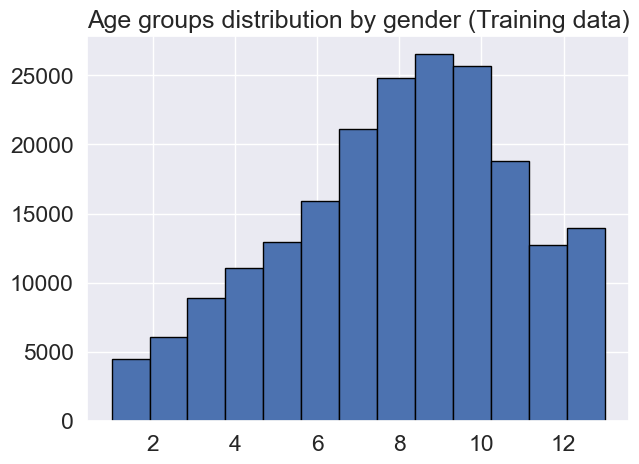

In [ ]:
plt.figure(figsize=(7,5))
sns.set_theme(font_scale=1.5)
plt.hist(dfTrain['Age'], bins=13, edgecolor='black')
plt.title('Age groups distribution by gender (Training data)')

Text(0.5, 1.0, 'Diabetes distribution by gender (Training data)')

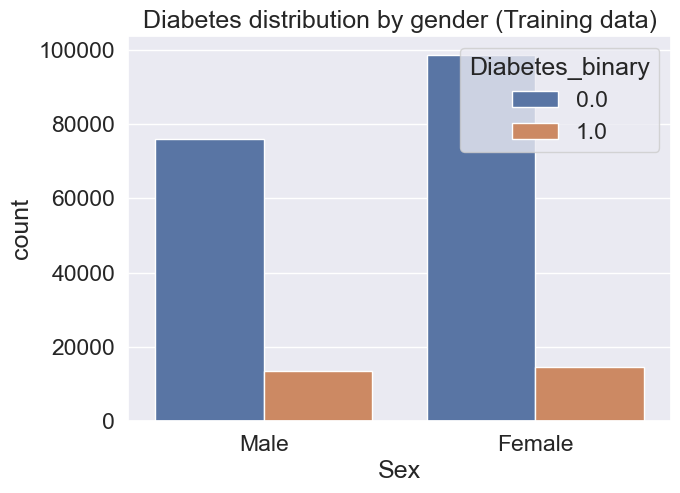

In [ ]:
dfTrainWithGender = dfTrain.copy()
dfTrainWithGender['Sex'] = dfTrainWithGender['Sex'].replace({0: 'Female', 1: 'Male'})

plt.figure(figsize=(7,5))
sns.set_theme(font_scale=1.5)
sns.countplot(x='Sex', data=dfTrainWithGender, hue="Diabetes_binary")
plt.title('Diabetes distribution by gender (Training data)')

Text(0.5, 1.0, 'Distribution of BMI (Training data)')

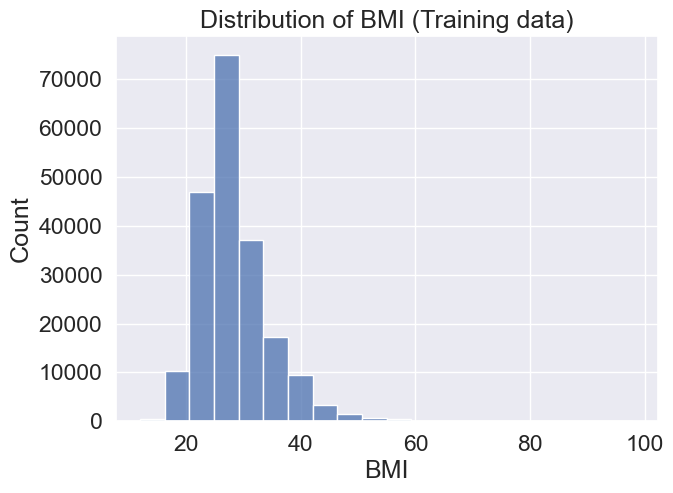

In [171]:
plt.figure(figsize=(7,5))
sns.histplot(dfTrain['BMI'], bins=20)
plt.title('Distribution of BMI (Training data)')

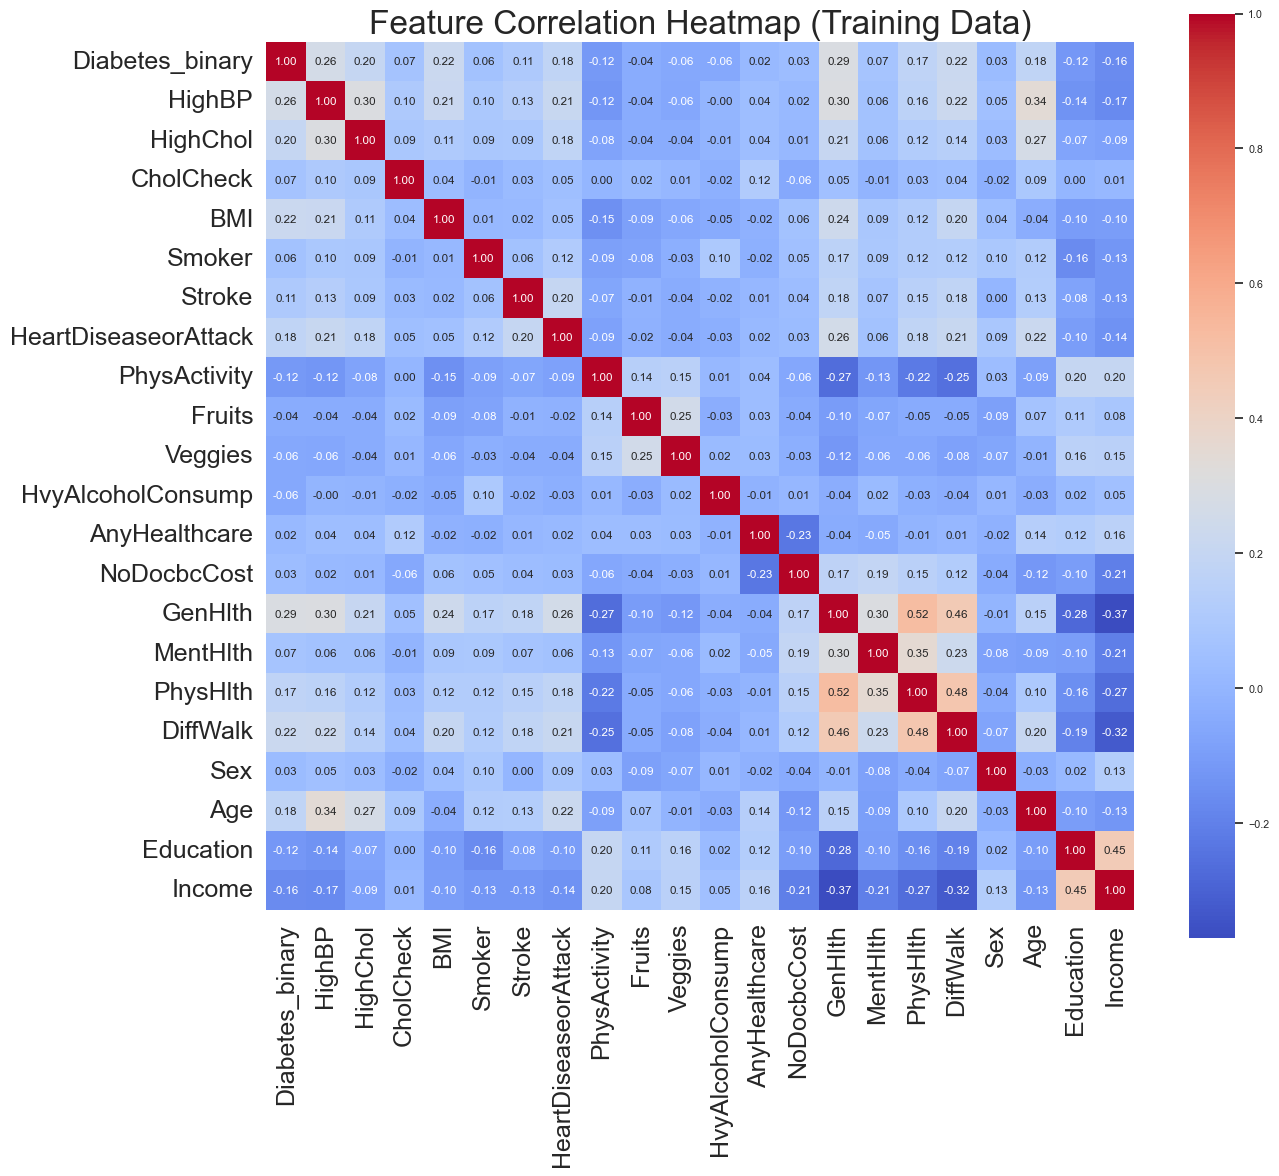

In [172]:
numeric_df = dfTrain.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

sns.set_theme(font_scale=0.7, )
plt.figure(figsize=(14, 12))
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
)
plt.title("Feature Correlation Heatmap (Training Data)", fontsize=24)
plt.xticks(fontsize=18, rotation=90)
plt.yticks(fontsize=18, rotation=0)
plt.show()

In [173]:
# Split data into features and target variable
x_train = dfTrain.drop(columns=['Diabetes_binary'])
y_train = dfTrain['Diabetes_binary']
x_test = dfTest.drop(columns=['Diabetes_binary'])
y_test = dfTest['Diabetes_binary']

print ("x_train shape:", x_train.shape)

x_train shape: (202944, 21)


In [174]:
# Balance the classes in the training set with under and oversampling (Only training)
sampling_pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
    ('under', RandomUnderSampler(sampling_strategy=0.8, random_state=42))
])

X_resampled, y_resampled = sampling_pipeline.fit_resample(x_train, y_train)

In [175]:
# Preprocessing pipelines for both numeric and categorical data
numeric_cols = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = x_train.select_dtypes(include=['object', 'category']).columns.tolist()


numeric_transform = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transform = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transform, numeric_cols),
    ('cat', categorical_transform, categorical_cols)
])

# Create pipelines for each model
logisticModel = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight={0:1, 1:2}))
])
randomForestModel = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight={0:1, 1:2}))
])
decisionTreeModel = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(class_weight={0:1, 1:2}))
])

# Train the models
logisticModel.fit(X_resampled, y_resampled)
randomForestModel.fit(X_resampled, y_resampled)
decisionTreeModel.fit(X_resampled, y_resampled)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [180]:
# Evaluate the accuracy of each model
threshold = 0.35

def evaluate_with_threshold(model, x_test, y_test, threshold=0.35):
    if hasattr(model.named_steps['model'], 'predict_proba'):
        y_probs = model.predict_proba(x_test)[:, 1]
    else:
        y_probs = model.decision_function(x_test)
        y_probs = (y_probs - y_probs.min()) / (y_probs.max() - y_probs.min())
    y_pred = (y_probs > threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    print(f"Threshold: {threshold}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall (Sensitivity): {recall:.2f}")
    print(f"False Negatives: {cm[1,0]}")
    return cm, recall

print("Logistic Regression with threshold adjustment:")
evaluate_with_threshold(logisticModel, x_test, y_test, threshold)

print("Decision Tree with threshold adjustment:")
evaluate_with_threshold(decisionTreeModel, x_test, y_test, threshold)

print("Random Forest with threshold adjustment:")
evaluate_with_threshold(randomForestModel, x_test, y_test, threshold)

# https://www.geeksforgeeks.org/machine-learning/methods-to-minimize-false-negatives-and-false-positives-in-binary-classification/#methods-to-minimize-false-negatives

Logistic Regression with threshold adjustment:
Threshold: 0.35
Confusion Matrix:
 [[21405 22262]
 [  488  6581]]
Recall (Sensitivity): 0.93
False Negatives: 488
Decision Tree with threshold adjustment:
Threshold: 0.35
Confusion Matrix:
 [[36121  7546]
 [ 4226  2843]]
Recall (Sensitivity): 0.40
False Negatives: 4226
Random Forest with threshold adjustment:
Threshold: 0.35
Confusion Matrix:
 [[36275  7392]
 [ 3095  3974]]
Recall (Sensitivity): 0.56
False Negatives: 3095


(array([[36275,  7392],
        [ 3095,  3974]]),
 0.5621728674494271)

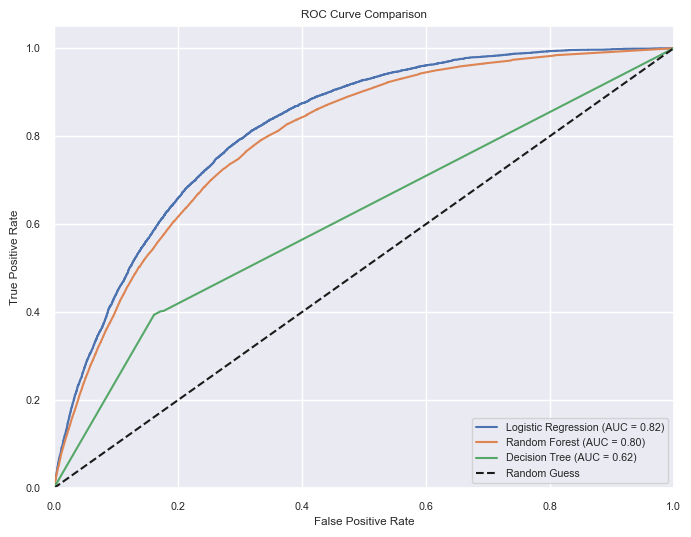

In [177]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
plt.figure(figsize=(8, 6))

y_score_logistic = logisticModel.predict_proba(x_test)[:, 1] if hasattr(logisticModel, "predict_proba") else logisticModel.decision_function(x_test)
fpr_log, tpr_log, _ = roc_curve(y_test, y_score_logistic)
roc_auc_log = auc(fpr_log, tpr_log)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')

if hasattr(randomForestModel, "decision_function"):
    y_score_forest = randomForestModel.decision_function(x_test)
else:
    y_score_forest = randomForestModel.predict_proba(x_test)[:, 1]
fpr_forest, tpr_forest, _ = roc_curve(y_test, y_score_forest)
roc_auc_forest = auc(fpr_forest, tpr_forest)
plt.plot(fpr_forest, tpr_forest, label=f'Random Forest (AUC = {roc_auc_forest:.2f})')

y_score_tree = decisionTreeModel.predict_proba(x_test)[:, 1] if hasattr(decisionTreeModel, "predict_proba") else decisionTreeModel.decision_function(x_test)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_score_tree)
roc_auc_tree = auc(fpr_tree, tpr_tree)
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {roc_auc_tree:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

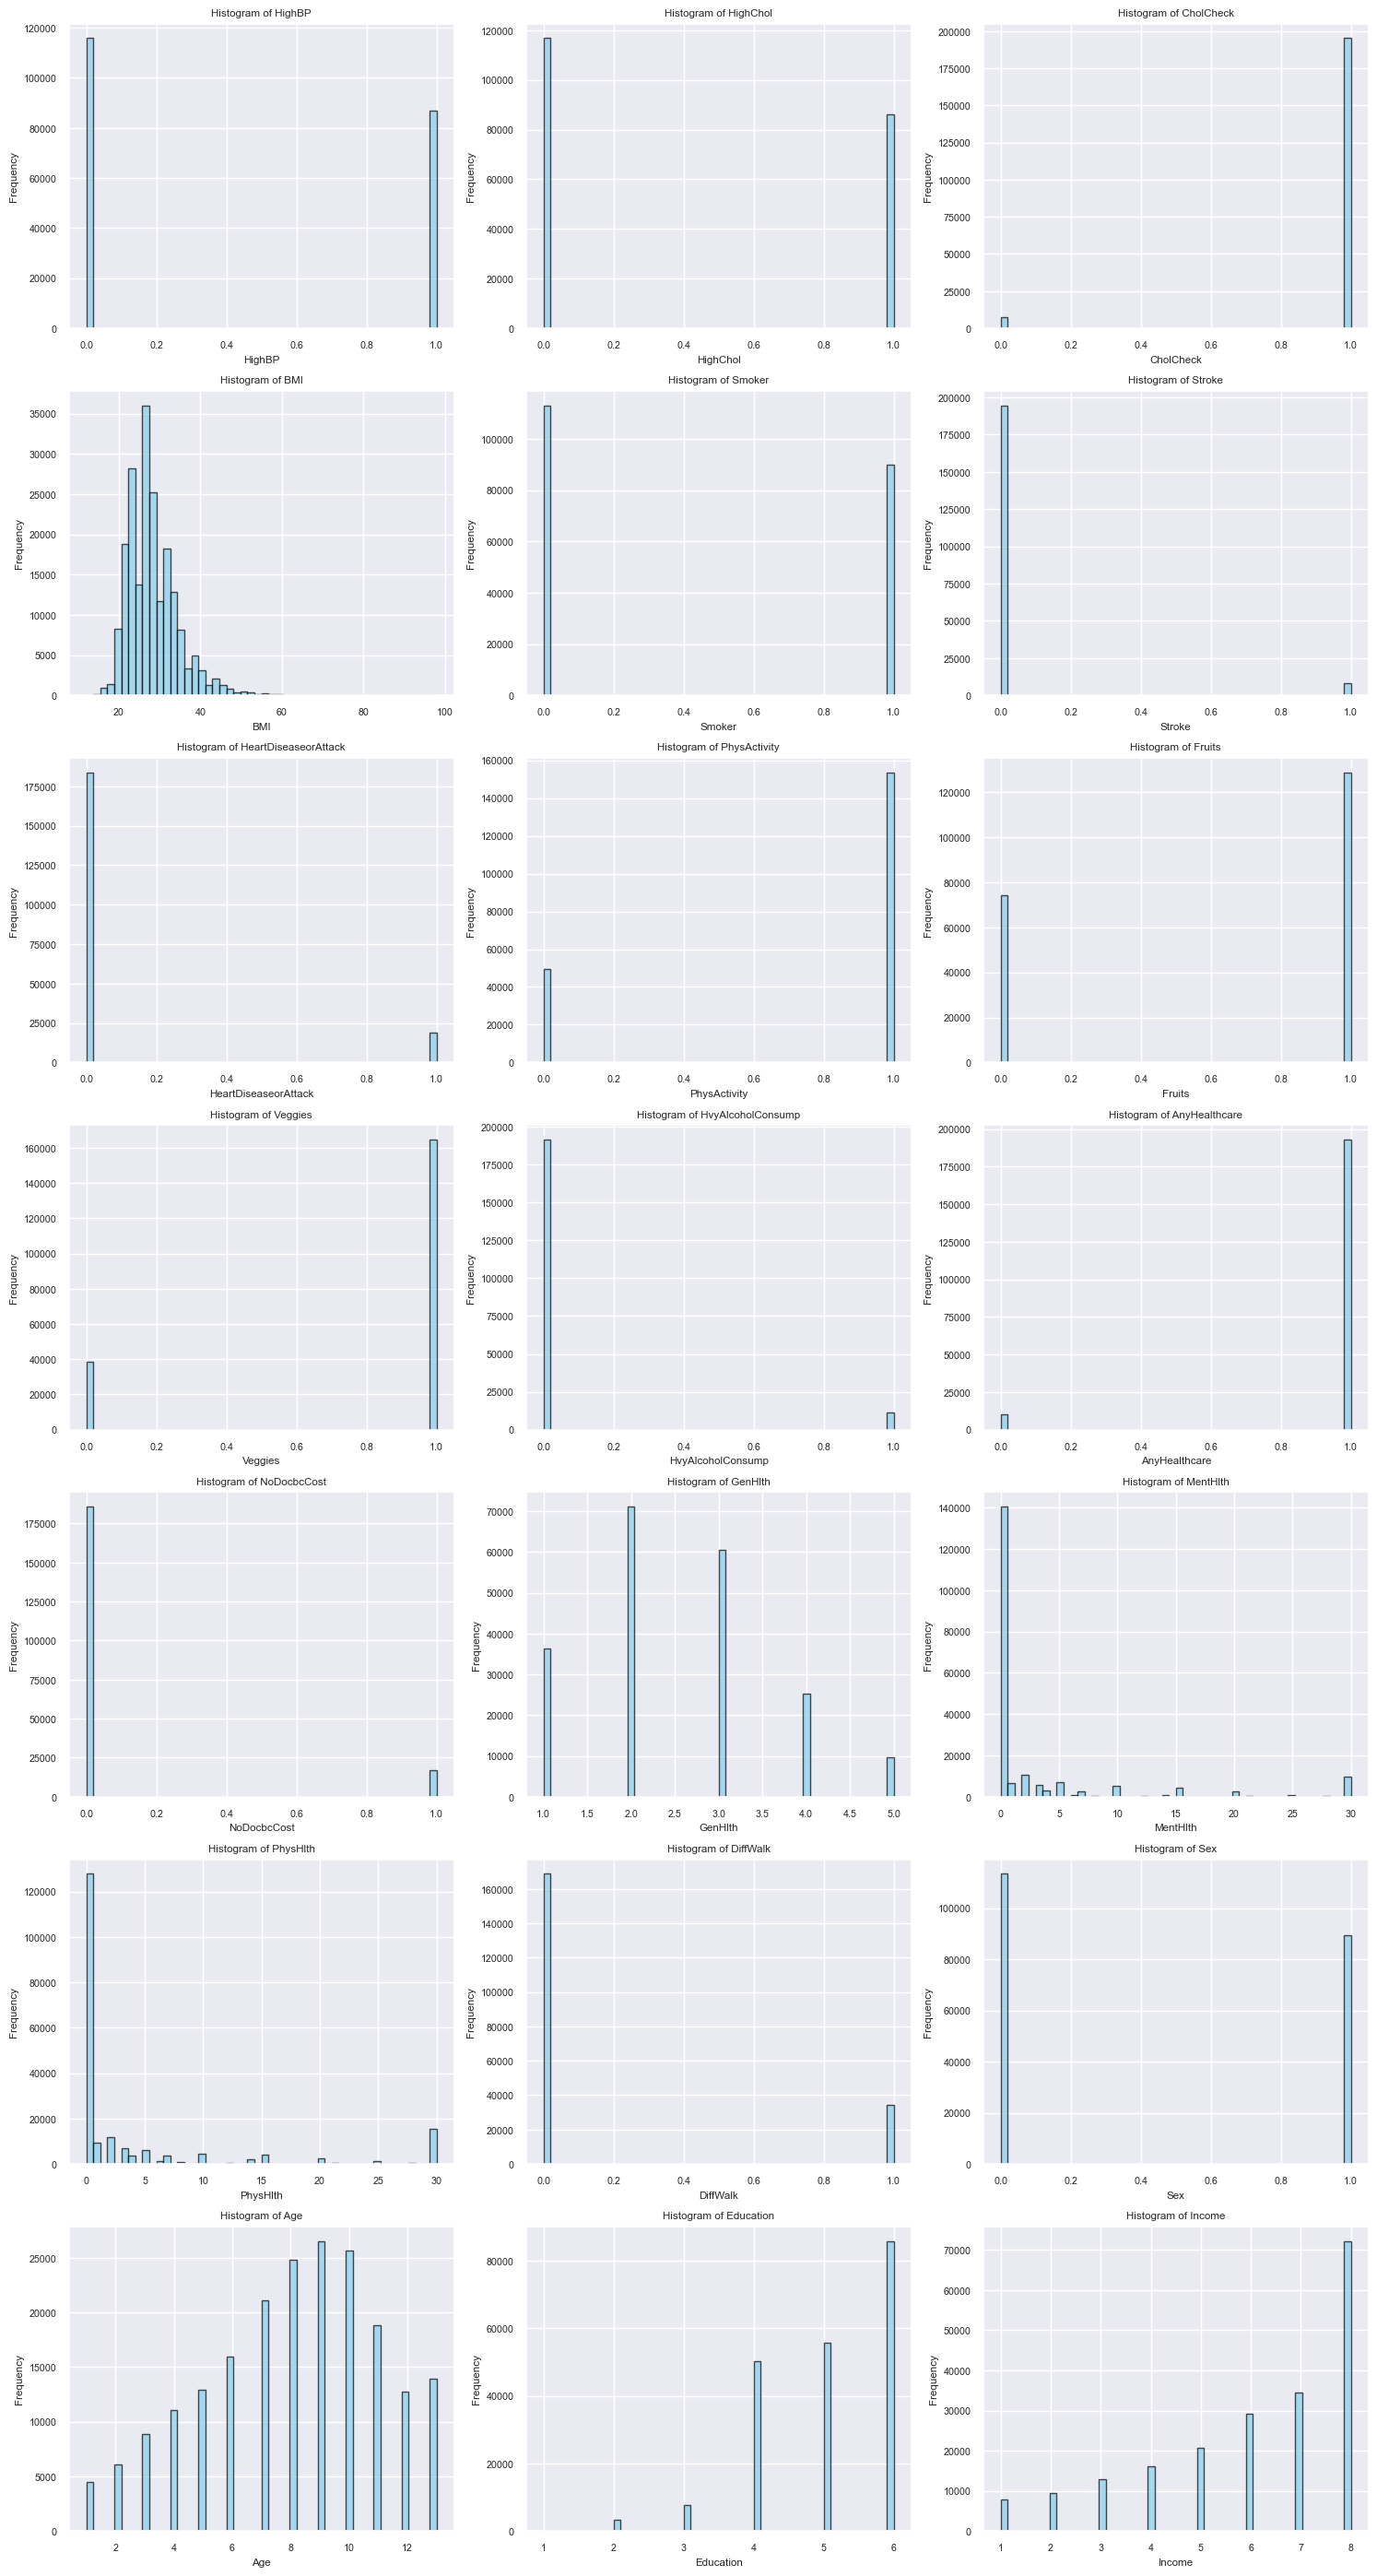

In [178]:
numeric_df = dfTrain.select_dtypes(include='number')
numeric_cols = [col for col in numeric_df.columns if col != 'Diabetes_binary']
n_cols = 3  # Number of columns in the grid
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(dfTrain[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].grid(True)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()